# Сначала подготовим единый датасет

In [ ]:
import os
import json
import pandas as pd
from collections import defaultdict



def load_epicrisis_data(folder_path):
    """Загружает все эпикризы из папки в единый датафрейм"""
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            
            with open(file_path, 'r', encoding='utf-8') as f:
                epicrisis = json.load(f)
                
                # Собираем все текстовые части
                text_parts = []
                
                # Жалобы
                if epicrisis.get('complaints') and epicrisis['complaints'].get('processed_text'):
                    text_parts.append(epicrisis['complaints']['processed_text'])
                
                # Анамнез заболевания
                if epicrisis.get('disease_history') and epicrisis['disease_history'].get('processed_text'):
                    text_parts.append(epicrisis['disease_history']['processed_text'])
                
                # Физикальное обследование
                if epicrisis.get('physical_examination') and epicrisis['physical_examination'].get('processed_text'):
                    text_parts.append(epicrisis['physical_examination']['processed_text'])
                
                # Собираем числовые параметры
                numeric_params = {}
                if epicrisis.get('numeric_parameters'):
                    for param_name, param_data in epicrisis['numeric_parameters'].items():
                        numeric_params[param_name] = param_data.get('value')
                
                # Целевой текст - объединяем все части
                target_text = ' '.join(text_parts)
                
                data.append({
                    'file_id': filename,
                    'diagnosis': epicrisis.get('diagnosis', {}).get('display_name', ''),
                    'diagnosis_code': epicrisis.get('diagnosis', {}).get('diagnosis_text', ''),
                    'complaints': epicrisis.get('complaints', {}).get('processed_text', ''),
                    'disease_history': epicrisis.get('disease_history', {}).get('processed_text', ''),
                    'physical_examination': epicrisis.get('physical_examination', {}).get('processed_text', ''),
                    'target_text': target_text,
                    'numeric_parameters': numeric_params,
                    'text_length': len(target_text)
                })
    
    return pd.DataFrame(data)

# Загрузка данных
folder_path = r"C:\Users\ckopn\Desktop\epikriz\Epikriz_project\epi_rash\preprocessed_medical_results"
df = load_epicrisis_data(folder_path)

# Анализ
print(f"Загружено {len(df)} эпикризов")
print(f"Средняя длина текста: {df['text_length'].mean():.0f} символов")
print(f"Диагнозы: {df['diagnosis'].value_counts().head()}")
import matplotlib.pyplot as plt
import seaborn as sns

Загружено 2013 эпикризов
Средняя длина текста: 1571 символов
Диагнозы: diagnosis
Другая уточненная хроническая обструктивная легочная болезнь                                      167
Злокачественное новообразование верхней доли, бронхов или легкого                                 141
Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры    138
Злокачественное новообразование нижней доли, бронхов или легкого                                  113
COVID-19, вирус идентифицирован                                                                    88
Name: count, dtype: int64


# Подготовка данных для CatBoost

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import json
import os


def count_symptoms(text):
    """Подсчет количества уникальных симптомов в тексте"""
    symptom_words = {
        'температура', 'лихорадка', 'кашель', 'одышка', 'боль', 'слабость',
        'тошнота', 'рвота', 'головная', 'хрипы', 'насморк', 'озноб'
    }
    return sum(1 for word in symptom_words if word in text)


def count_medical_terms(text):
    """Подсчет медицинских терминов в тексте"""
    medical_terms = {
        'гипертермия', 'диспноэ', 'тахикардия', 'цианоз', 'отек', 'крепитация',
        'аускультация', 'перкуторно', 'пальпация', 'аускультативно'
    }
    return sum(1 for term in medical_terms if term in text)


def prepare_catboost_features(df):
    """Улучшенная подготовка признаков для CatBoost"""
    
    features_list = []
    
    for idx, row in df.iterrows():
        features = {}
        
        # 1. Числовые параметры (основные витальные признаки)
        numeric_params = row['numeric_parameters']
        vital_signs = [
            'Температура тела', 'Артериальное давление систолическое',
            'Артериальное давление диастолическое', 'Частота сердечных сокращений',
            'Пульс', 'Сатурация', 'Частота дыхания'
        ]
        
        for sign in vital_signs:
            features[f'num_{sign}'] = numeric_params.get(sign, 0) or 0
        
        # 2. Лабораторные показатели
        lab_tests = [
            'Гематокрит крови методом автоматизированного подсчёта',
            'Лейкоциты, количество в крови методом автоматизированного подсчёта',
            'Нейтрофилы, абсолютное количество в крови методом автоматизированного подсчёта',
            'Белок общий, массовая концентрация в сыворотке или плазме крови',
            'Глюкоза, молярная концентрация в сыворотке или плазме крови'
        ]
        
        for test in lab_tests:
            features[f'lab_{test}'] = numeric_params.get(test, 0) or 0

        # 3. УЛУЧШЕННЫЕ текстовые признаки 
        complaints_text = (row['complaints'] or '').lower()
        history_text = (row['disease_history'] or '').lower()
        examination_text = (row['physical_examination'] or '').lower()
        
        # Информативные метрики 
        features['symptom_density'] = count_symptoms(complaints_text) / (len(complaints_text) + 1) * 1000
        features['medical_term_density'] = count_medical_terms(complaints_text + history_text) / (len(complaints_text + history_text) + 1) * 1000
        
        # 4. УЛУЧШЕННЫЕ признаки из жалоб
        symptom_keywords = {
            'fever': ['температура', 'лихорадка', 'субфебрильный', 'озноб', 'жар', 'гипертермия'],
            'cough': ['кашель', 'кашлять', 'мокрота', 'отхаркивание', 'продуктивный', 'непродуктивный'],
            'breathlessness': ['одышка', 'одышку', 'затруднение дыхания', 'не хватает воздуха', 'диспноэ'],
            'chest_pain': ['боль в груди', 'болит грудь', 'боль в грудной', 'кардиалгия'],
            'weakness': ['слабость', 'усталость', 'недомогание', 'астения'],
            'headache': ['головная боль', 'болит голова', 'цефалгия'],
            'nausea': ['тошнота', 'рвота', 'тошнит'],
            'wheezing': ['хрипы', 'свистящее', 'свист'],
            'sputum': ['мокрота', 'слизь', 'отделяемое'],
            'rhinitis': ['насморк', 'ринит', 'заложенность носа']
        }

        for symptom_name, keywords in symptom_keywords.items():
            features[f'symp_{symptom_name}'] = 1 if any(keyword in complaints_text for keyword in keywords) else 0

        # 5. КОМБИНИРОВАННЫЕ симптомы (более информативные)
        features['respiratory_syndrome'] = features.get('symp_cough', 0) + features.get('symp_breathlessness', 0) + features.get('symp_wheezing', 0)
        features['inflammatory_syndrome'] = features.get('symp_fever', 0) + features.get('symp_weakness', 0)
        
        # 6. Признаки из анамнеза
        history_keywords = {
            'smoking': ['курение', 'курит', 'курильщик', 'табак', 'сигарет'],
            'chronic_lung': ['хобл', 'астма', 'бронхит', 'эмфизема', 'хронический бронхит'],
            'hypertension': ['гипертония', 'давление', 'артериальная гипертензия'],
            'diabetes': ['диабет', 'сахарный', 'глюкоза'],
            'cardiac': ['сердце', 'ишемия', 'инфаркт', 'стенокардия'],
            'allergy': ['аллергия', 'аллергический', 'сенная лихорадка']
        }

        for history_name, keywords in history_keywords.items():
            features[f'hist_{history_name}'] = 1 if any(keyword in history_text for keyword in keywords) else 0

        # 7. Признаки из физикального обследования
        examination_keywords = {
            'wheezing_auscultation': ['хрипы', 'свистящие', 'жесткое дыхание', 'ослабленное'],
            'crepitation': ['крепитация', 'влажные хрипы'],
            'cyanosis': ['цианоз', 'синюшность', 'акроцианоз'],
            'edema': ['отек', 'отеки', 'пастозность'],
            'tachycardia': ['тахикардия', 'учащенное сердцебиение']
        }

        for exam_name, keywords in examination_keywords.items():
            features[f'exam_{exam_name}'] = 1 if any(keyword in examination_text for keyword in keywords) else 0

        # 8. Сводные счетчики значимых факторов
        features['total_symptoms_count'] = sum(1 for key in features.keys() if key.startswith('symp_') and features[key] == 1)
        features['total_history_factors'] = sum(1 for key in features.keys() if key.startswith('hist_') and features[key] == 1)
        features['total_exam_findings'] = sum(1 for key in features.keys() if key.startswith('exam_') and features[key] == 1)
        
        features_list.append(features)
    
    return pd.DataFrame(features_list)


# Подготовка признаков
print("Подготовка улучшенных признаков...")
features_df = prepare_catboost_features(df)

# Целевая переменная - диагноз (топ-10 самых частых диагнозов для устойчивости)
top_diagnoses = df['diagnosis'].value_counts().head(10).index
df_filtered = df[df['diagnosis'].isin(top_diagnoses)].copy()
features_filtered = features_df.loc[df_filtered.index]

print(f"Осталось {len(df_filtered)} записей после фильтрации по топ-10 диагнозам")
print(f"Всего признаков: {features_filtered.shape[1]}")
print("Топ диагнозов:", top_diagnoses.tolist())

# Детальная информация о созданных признаках
print(f"\nСоздано признаков по категориям:")
print(f"- Числовые витальные признаки: {len([col for col in features_filtered.columns if col.startswith('num_')])}")
print(f"- Лабораторные показатели: {len([col for col in features_filtered.columns if col.startswith('lab_')])}")
print(f"- Симптомы из жалоб: {len([col for col in features_filtered.columns if col.startswith('symp_')])}")
print(f"- Признаки из анамнеза: {len([col for col in features_filtered.columns if col.startswith('hist_')])}")
print(f"- Физикальные находки: {len([col for col in features_filtered.columns if col.startswith('exam_')])}")
print(f"- Комбинированные синдромы: {len([col for col in features_filtered.columns if 'syndrome' in col])}")
print(f"- Сводные метрики: {len([col for col in features_filtered.columns if 'total_' in col or 'density' in col])}")



Подготовка улучшенных признаков...
Осталось 976 записей после фильтрации по топ-10 диагнозам
Всего признаков: 40
Топ диагнозов: ['Другая уточненная хроническая обструктивная легочная болезнь', 'Злокачественное новообразование верхней доли, бронхов или легкого', 'Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры', 'Злокачественное новообразование нижней доли, бронхов или легкого', 'COVID-19, вирус идентифицирован', 'Другие бактериальные пневмонии', 'Доброкачественное новообразование бронха и легкого', 'Астма неуточненная', 'Туберкулез легких при отрицательных результатах бактериологических и гистологических исследований', 'Неаллергическая астма']

Создано признаков по категориям:
- Числовые витальные признаки: 7
- Лабораторные показатели: 5
- Симптомы из жалоб: 10
- Признаки из анамнеза: 6
- Физикальные находки: 5
- Комбинированные синдромы: 2
- Сводные метрики: 5


In [28]:
# Подготовка данных для обучения
X = features_filtered
y = df_filtered['diagnosis']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Инициализация CatBoost
model = CatBoostClassifier(
    iterations=3000, 
    learning_rate=0.08,
    depth=6,
    loss_function='MultiClass',
    verbose=100,
    random_state=42,
    early_stopping_rounds=100,  # Ждем улучшения 100 итераций
)

# Обучение модели
print("Обучение CatBoost модели...")
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    plot=True
)

Train size: 780, Test size: 196
Обучение CatBoost модели...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 2.2145337	test: 2.2192549	best: 2.2192549 (0)	total: 8.01ms	remaining: 24s
100:	learn: 0.6304636	test: 0.8952447	best: 0.8952447 (100)	total: 740ms	remaining: 21.2s
200:	learn: 0.3880599	test: 0.7946549	best: 0.7946549 (200)	total: 1.47s	remaining: 20.4s
300:	learn: 0.2737446	test: 0.7598654	best: 0.7592322 (299)	total: 2.17s	remaining: 19.5s
400:	learn: 0.2044971	test: 0.7485834	best: 0.7480715 (398)	total: 2.88s	remaining: 18.7s
500:	learn: 0.1592980	test: 0.7382117	best: 0.7378652 (496)	total: 3.6s	remaining: 17.9s
600:	learn: 0.1281981	test: 0.7319852	best: 0.7319082 (599)	total: 4.31s	remaining: 17.2s
700:	learn: 0.1071112	test: 0.7308389	best: 0.7292354 (661)	total: 5.02s	remaining: 16.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7292353705
bestIteration = 661

Shrink model to first 662 iterations.


# Просмотр метрик


ТОП-15 САМЫХ ВАЖНЫХ ПРИЗНАКОВ
                                              feature  importance
12                                    symptom_density    9.455398
6                                 num_Частота дыхания    9.371158
0                                num_Температура тела    9.067708
8   lab_Лейкоциты, количество в крови методом авто...    8.253700
5                                       num_Сатурация    7.466638
4                                           num_Пульс    5.486335
26                                       hist_smoking    5.202348
11  lab_Глюкоза, молярная концентрация в сыворотке...    5.179379
10  lab_Белок общий, массовая концентрация в сывор...    4.863485
2            num_Артериальное давление диастолическое    4.668140
3                    num_Частота сердечных сокращений    3.904008
1             num_Артериальное давление систолическое    3.740036
25                              inflammatory_syndrome    3.429888
24                               respiratory_

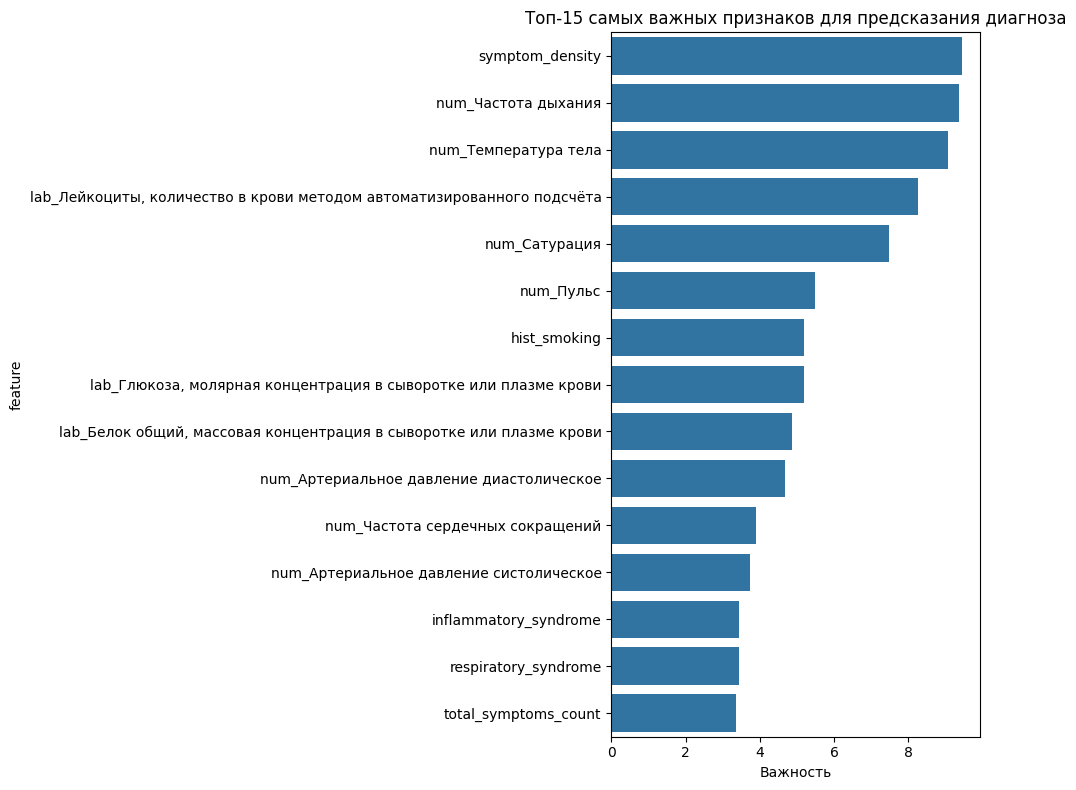

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Важность признаков
feature_importance = model.get_feature_importance()
feature_names = X.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("ТОП-15 САМЫХ ВАЖНЫХ ПРИЗНАКОВ")
print("="*50)
print(importance_df.head(15))

# Визуализация важности признаков
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Топ-15 самых важных признаков для предсказания диагноза')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

In [30]:
# Предсказания на тестовой выборке
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Метрики качества
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.3f}")
print(f"Размер тестовой выборки: {len(y_test)} примеров")

# Детальный отчет по классификации
print("\n" + "="*50)
print("ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ")
print("="*50)
print(classification_report(y_test, y_pred, target_names=top_diagnoses))

Точность модели: 0.714
Размер тестовой выборки: 196 примеров

ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ
                                                                                                   precision    recall  f1-score   support

                                     Другая уточненная хроническая обструктивная легочная болезнь       0.90      1.00      0.95        18
                                Злокачественное новообразование верхней доли, бронхов или легкого       0.90      0.64      0.75        14
   Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры       0.85      0.79      0.81        14
                                 Злокачественное новообразование нижней доли, бронхов или легкого       0.84      0.97      0.90        33
                                                                  COVID-19, вирус идентифицирован       0.86      0.75      0.80        16
                                                                   Дру